# Dimension Reduction

We will perform the following two strategies to reduce the feature dimension to make our data better suited for ML training.

1. Feature Selection
2. Rescaling + Principal Component Analysis (PCA)

The main Python Library we will use is `scikit-learn`.

## 1. A Simple PCA example

Let's sythesize some data with two highly correlated features.

In [1]:
import numpy as np # use numpy for matrix operations
from matplotlib import pyplot as plt # plotting

In [2]:
# Feature matrix
X = np.array([[-1, -0.98],
              [0.1, -0.05],
              [1.1, 1.0]])

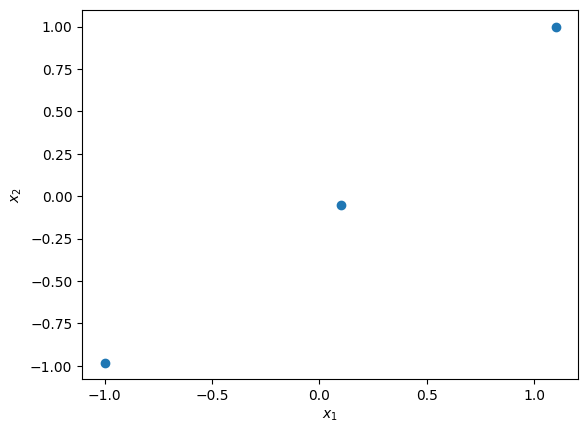

In [3]:
# visualize the data - for two features, you can simply plot them
plt.scatter(X[:, 0], X[:, 1]) # X[:, i] means the i-th column of the X matrix
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

In [4]:
# Construct the covariance matrix
S = np.dot(X.T, X)/(X.shape[0] - 1) # np.dot(A, B) does matrix multiplication between A and B
print(S)


[[1.11    1.0375 ]
 [1.0375  0.98145]]


In [5]:
# Diagonalize S
eigenvalues, eigenvectors = np.linalg.eig(S) # numpy.linalg provides many linear algebra functions
print(eigenvalues)

[2.08521407 0.00623593]


In [6]:
# We choose the first eigenvector as the principal component, the Feature matrix becomes
Z = np.dot(X, eigenvectors[:, 0])
print(Z)

[-1.39983894  0.0386192   1.4864009 ]


## 2. Application to the ESOL Dataset

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [8]:
!mkdir -p "lab6"
!wget -q -O "lab6/delaney_solubility.csv" "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab5/data/delaney_solubility.csv"

In [9]:
df = pd.read_csv("lab6/delaney_solubility.csv", index_col=False)
print(df.columns) # you can see what columns are there

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='object')


In [11]:
# features
feature_cols = [
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
X = df[feature_cols].values # each column of X is one feature
print(X.shape)

(1128, 6)


### Use Feature Selection based on Variance

In [12]:
X_selected = VarianceThreshold(threshold=0.1).fit_transform(X) # feature selection
# vt = VarianceThreshold(threshold=0.1)
# vt.fit(X)
# print(vt.variances_)
print(X_selected.shape)

(1128, 5)


### Use Rescaling + PCA

In [14]:
X_scaled = StandardScaler().fit_transform(X) # rescale the features

In [15]:
pca = PCA(n_components=5) # we also pick 5 components
Z = pca.fit_transform(X_scaled)
print(Z.shape)

(1128, 5)


#### We can look at the PC vectors

In [18]:
PC_vectors = pca.components_
print(PC_vectors.shape) # each row is a principal component
print(PC_vectors[0])

(5, 6)
[-0.11623099  0.51134976  0.46035173  0.37364676  0.25448541  0.55561978]


In [ ]:
# Let's see which features are dominant by looking at the first PC
for i in range(len(feature_cols)):
    print(f"{feature_cols[i]}: {PC_vectors[0, i]}")

Minimum Degree: -0.1162309892367983
Molecular Weight: 0.511349756435846
Number of H-Bond Donors: 0.46035172715610767
Number of Rings: 0.3736467628598428
Number of Rotatable Bonds: 0.2544854092238632
Polar Surface Area: 0.5556197837864925


| Feature                   | Weight | Interpretation                                      |
| ------------------------- | ------ | --------------------------------------------------- |
| Polar Surface Area        | 0.556  | Largest contributor — main driver of variance       |
| Molecular Weight          | 0.511  | Very important — also strongly correlated with size |
| Number of H-Bond Donors   | 0.460  | Important for polarity patterns                     |
| Number of Rings           | 0.374  | Moderate contribution — structural diversity        |
| Number of Rotatable Bonds | 0.254  | Smaller contribution — secondary effect             |
| Minimum Degree            | 0.116  | Least contribution — minor role in PC1              |


### 3. Optional Train Linear Regression

In [19]:
from sklearn.model_selection import train_test_split # used to split the dataset into training and testing subsets
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression # models
# from sklearn.preprocessing import StandardScaler # rescale the feature values
from sklearn import metrics # metrics for performance

In [20]:
y = df["measured log solubility in mols per litre"].values

### Linear Regression with the original data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0,
)

In [22]:
# linear regression
linreg = LinearRegression() # initiate the linear regression object
linreg.fit(X_train, y_train) # train the data

y_pred = linreg.predict(X_test) # get prediction

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) # RMSE score
r2_lr = metrics.r2_score(y_test, y_pred) # R2 score

print("RMSE error:", rmse_lr)
print("R2 score:", r2_lr)

RMSE error: 1.2120653170881208
R2 score: 0.694373851280627


### Linear Regression with Feature Selected Data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=0,
)
# linear regression
linreg = LinearRegression() # initiate the linear regression object
linreg.fit(X_train, y_train) # train the data

y_pred = linreg.predict(X_test) # get prediction

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) # RMSE score
r2_lr = metrics.r2_score(y_test, y_pred) # R2 score

print("RMSE error:", rmse_lr)
print("R2 score:", r2_lr)

RMSE error: 1.2026752420750049
R2 score: 0.6990909829499073


### Linear Regression with PCA

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    Z, y, test_size=0.2, random_state=0,
)
# linear regression
linreg = LinearRegression() # initiate the linear regression object
linreg.fit(X_train, y_train) # train the data

y_pred = linreg.predict(X_test) # get prediction

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) # RMSE score
r2_lr = metrics.r2_score(y_test, y_pred) # R2 score

print("RMSE error:", rmse_lr)
print("R2 score:", r2_lr)

RMSE error: 1.201661876521761
R2 score: 0.6995978568849597


## Save the model

In [25]:
import joblib

In [26]:
# save model
joblib.dump(linreg, 'my_model.joblib') # Save

# load model
loaded_model = joblib.load('my_model.joblib') # Load

In [27]:
# use the model
y_pred = loaded_model.predict(X_test)